# Imports

In [ ]:
!pip install nltk

In [ ]:
import torch
import torch.nn as nn
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import joblib
from torch.nn.utils.rnn import pad_sequence
import torch
import numpy as np
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk.tokenize import word_tokenize
import string


# Data Handling

In [ ]:
"""
class_data = pd.read_csv('../data/new_class_dataset.csv')
print(class_data.columns)

#no reduction
#max_chars = 300
#class_data['input'] = class_data['input'].astype(str).str.slice(0, max_chars)

split_class_data = class_data.sample(frac=0.1, random_state=42).reset_index(drop=True)
tiny_class_data = class_data.sample(n=32, random_state=42).reset_index(drop=True)

"""

# Tokenizing the data

In [ ]:
"""
import re
from collections import Counter

nltk.download('stopwords') #remove stopwords
nltk.download('punkt') #remove punctuation
nltk.download('punkt_tab') #needed for further tokenization
nltk.download('wordnet')
nltk.download('omw-1.4')

# get pretrained weights from GloVe
glove_path = "../glove.6B/glove.6B.100d.txt"
glove_dict = {}

with open(glove_path, 'r', encoding='utf8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.array(values[1:], dtype='float32')
        glove_dict[word] = vector

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    
    text = text.lower().strip()
    text = re.sub(f"[{re.escape(string.punctuation)}]", "", text)

    # Tokenize text into words
    tokens = word_tokenize(text)

    # Remove stopwords
    tokens = [t for t in tokens if t not in stop_words]
    
    # Lemmatize tokens
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    # Join back into string
    return " ".join(tokens)


#remove stopwords
split_class_data['input'] = split_class_data['input'].apply(preprocess_text)

# Tokenize all texts
split_class_data['tokens'] = split_class_data['input'].apply(word_tokenize)

# Flatten all tokens
all_tokens = [token for tokens in split_class_data['tokens'] for token in tokens]
token_counts = Counter(all_tokens)

# Create word2idx dictionary (start from 2 to reserve 0 for PAD, 1 for UNK)
# only use the 25'000 most common words
n_words = 10000
vocab_size = n_words + 2
vocab = {word: i+2 for i, (word, _) in enumerate(token_counts.most_common())}
vocab['<PAD>'] = 0
vocab['<UNK>'] = 1

embedding_matrix = np.zeros((len(vocab), 100))
for word, idx in vocab.items():
    if word in glove_dict:
        embedding_matrix[idx] = glove_dict[word]
    else:
        embedding_matrix[idx] = np.random.normal(scale=0.6, size=100)

def encode_tokens(tokens, vocab):
    return [vocab.get(token, vocab['<UNK>']) for token in tokens]

split_class_data['encoded'] = split_class_data['tokens'].apply(lambda tokens: encode_tokens(tokens, vocab))

# Convert to tensors
sequence_tensors = [torch.tensor(seq) for seq in split_class_data['encoded']]
padded_seqs = pad_sequence(sequence_tensors, batch_first=True, padding_value=vocab['<PAD>'])

max_len = max(len(seq) for seq in sequence_tensors)
print("Max sequence length:", max_len)
"""

# Model & finetuning

In [ ]:
"""
class FakeNewsLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_layers):
        super(FakeNewsLSTM, self).__init__()
        
        self.text_embedding = nn.Embedding.from_pretrained(torch.tensor(embedding_matrix, dtype=torch.float32), freeze=False)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, num_layers=n_layers)
        
        
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64), #fix weights via transfer learning (keyword)
            nn.Linear(64, 32),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, text_seq):
        x = self.text_embedding(text_seq)
        _, (h_n, _) = self.lstm(x)
        lstm_output = h_n[-1]
        
        
        return self.fc(lstm_output)

print(split_class_data['input'].apply(len).max())
"""

## Early stopping

In [ ]:
"""
class EarlyStopping:
    def __init__(self, patience=3, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = float('inf')
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss - val_loss > self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
"""

## Train model (& freeze parameters)

In [ ]:
"""
from torch.utils.data import Dataset

file_path = "best_pure_classification_model.pkl"

class FakeNewsDataset(Dataset):
    def __init__(self, padded_seqs, labels):
        self.text = padded_seqs
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.text[idx], self.labels[idx]
    
from torch.utils.data import DataLoader, random_split


labels = split_class_data['label']
total_size = len(labels)
train_size = int(0.8 * total_size)
test_size = total_size - train_size

dataset = FakeNewsDataset(padded_seqs, labels)
train_ds, test_ds = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=32)
model = FakeNewsLSTM(vocab_size=len(vocab), embed_dim=100, hidden_dim=128, n_layers=2)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
early_stopping = EarlyStopping(patience=5)

num_epochs = 20


#freeze the first layer, as were using an embedding
for param in model.text_embedding.parameters():
    param.requires_grad = False


for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for text_batch, label_batch in train_loader:

        optimizer.zero_grad()
        preds = model(text_batch).squeeze(1)
        loss = criterion(preds, label_batch.float())
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    avg_train_loss = train_loss / len(train_loader)


    model.eval()
    val_loss = 0
    with torch.no_grad():
        for text_batch, label_batch in test_loader:
            preds = model(text_batch).squeeze(1)
            loss = criterion(preds, label_batch.float())
            val_loss += loss.item()
    
    avg_val_loss = val_loss / len(test_loader)
    print(f"Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    # Early stopping logic
    if avg_val_loss < early_stopping.best_loss:
        best_model_state = model.state_dict()

    early_stopping(avg_val_loss)
    if early_stopping.early_stop:
        print("Early stopping triggered.")
        break
from sklearn.metrics import accuracy_score


model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for text_batch, label_batch in test_loader:
        preds = model(text_batch).squeeze(1)
        predicted = (preds > 0.5).int()
        all_preds.extend(predicted.tolist())
        all_labels.extend(label_batch.tolist())

acc = accuracy_score(all_labels, all_preds)
print(f"Test Accuracy: {acc:.4f}")

model_bundle = {
    'model': model,
    'accuracy' : acc
}

try:
    prev_model_bundle = joblib.load(file_path)
    #found better model: save
    if model_bundle['accuracy'] > prev_model_bundle['accuracy']:
        print("better accuracy found, saving the model")
        joblib.dump(model_bundle, file_path)

except EOFError:
    print("File is empty or corrupted (EOFError). will save new model on it")
    joblib.dump(model_bundle, file_path)
"""

In [ ]:
"""
try:
    prev_model_bundle = joblib.load(file_path)
    #found better model: save
    if model_bundle['accuracy'] > prev_model_bundle['accuracy']:
        joblib.dump(model_bundle, file_path)

except EOFError:
    print("File is empty or corrupted (EOFError). will save new model on it")
    joblib.dump(model_bundle, file_path)

"""

## Sanity Check

In [ ]:
"""
tiny_class_data['input'] = tiny_class_data['input'].apply(preprocess_text)
tiny_class_data['tokens'] = tiny_class_data['input'].apply(word_tokenize)
tiny_class_data['encoded'] = tiny_class_data['tokens'].apply(lambda tokens: encode_tokens(tokens, vocab))

tiny_sequence_tensors = [torch.tensor(seq) for seq in tiny_class_data['encoded']]
tiny_padded_seqs = pad_sequence(sequence_tensors, batch_first=True, padding_value=vocab['<PAD>'])

tiny_labels = tiny_class_data['label'].reset_index(drop=True)

tiny_dataset = FakeNewsDataset(tiny_padded_seqs, tiny_labels)
tiny_loader = DataLoader(tiny_dataset, batch_size=8, shuffle=True)

model = FakeNewsLSTM(vocab_size=len(vocab), embed_dim=100, hidden_dim=128, n_layers=2)

# Optional: unfreeze embeddings
for param in model.text_embedding.parameters():
    param.requires_grad = True

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

for epoch in range(30):  # Should converge fast
    model.train()
    total_loss = 0
    for text_batch, label_batch in tiny_loader:
        optimizer.zero_grad()
        preds = model(text_batch).squeeze(1)
        loss = criterion(preds, label_batch.float())
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    avg_loss = total_loss / len(tiny_loader)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")
"""

# Tensorflow approach

## Dependencies

In [ ]:
import numpy as np
import pandas as pd
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.initializers import Constant
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
from collections import Counter


## Textual processing

In [ ]:
tf_class_data = pd.read_csv("../data/new_class_dataset.csv")
# --- Setup ---
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

MAX_TOKENS = 256

tf_stop_words = set(stopwords.words('english'))
tf_lemmatizer = WordNetLemmatizer()

# --- Preprocessing Function ---
def preprocess_text(text):
    if not(isinstance(text, str)):
        return ""
    text = text.lower()
    text = re.sub(f"[{re.escape(string.punctuation)}]", "", text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in tf_stop_words]
    tokens = [tf_lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)

# --- Load your dataset ---
# Assuming class_data is a pandas DataFrame with 'input' and 'label'
tf_class_data['input_clean'] = tf_class_data['input'].apply(preprocess_text)


# --- Tokenization ---
tf_tokenizer = Tokenizer(num_words=10000, oov_token='<UNK>')
tf_tokenizer.fit_on_texts(tf_class_data['input_clean'])
tf_sequences = tf_tokenizer.texts_to_sequences(tf_class_data['input_clean'])
print(len(tf_tokenizer.word_index))

all_tokens = [token for seq in tf_sequences for token in seq]

token_freq = Counter(all_tokens)
filtered_all_tokens = {token: freq for token, freq in token_freq.items() if freq <= 10000}


frequencies = list(filtered_all_tokens.values())
plt.figure(figsize=(10, 5))
plt.hist(frequencies, bins=100, log=True)  # log scale helps highlight the tail
plt.xlabel("Token Frequency")
plt.ylabel("Number of Tokens (log scale)")
plt.title("Token Frequency Distribution")
plt.show()

token_freq = Counter(all_tokens)

# Filter: exclude tokens with frequency below threshold (e.g., 5)
min_freq_threshold = 20
filtered_freqs = [freq for freq in token_freq.values() if freq >= min_freq_threshold]
MAX_TOKENS = len(filtered_freqs)
print(MAX_TOKENS)
MAX_TOKENS = 5000

tf_sequences = [seq[:MAX_TOKENS] for seq in tf_sequences]
tf_word_index = tf_tokenizer.word_index

tf_max_seq_length = max(len(seq) for seq in tf_sequences)
X = pad_sequences(tf_sequences, maxlen=tf_max_seq_length, padding='post')
y = tf_class_data['label'].astype(int).values

# --- Split ---
tf_X_train, tf_X_test, tf_y_train, tf_y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Load GloVe ---
tf_embedding_index = {}
with open("../glove.6B/glove.6B.100d.txt", 'r', encoding='utf8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype='float32')
        tf_embedding_index[word] = vector

tf_embedding_dim = 100
tf_embedding_matrix = np.zeros((len(tf_word_index) + 1, tf_embedding_dim))
for word, i in tf_word_index.items():
    embedding_vector = tf_embedding_index.get(word)
    if embedding_vector is not None:
        tf_embedding_matrix[i] = embedding_vector
    else:
        tf_embedding_matrix[i] = np.random.normal(scale=0.6, size=(tf_embedding_dim,))

## Model

In [ ]:
tf_model = Sequential([
    Embedding(input_dim=len(tf_word_index)+1,
              output_dim=tf_embedding_dim,
              embeddings_initializer=Constant(tf_embedding_matrix),
              input_length=tf_max_seq_length,
              trainable=False),
    LSTM(128),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

## Training model

In [ ]:
tf_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
tf_model.summary()

# --- Train ---
tf_model.fit(tf_X_train, tf_y_train, epochs=10, batch_size=32, validation_split=0.2)

# --- Evaluate ---
loss, accuracy = tf_model.evaluate(tf_X_test, tf_y_test)
print(f"Test Accuracy: {accuracy:.4f}")

## Sanity Check

In [ ]:

tiny_class_data = tf_class_data.sample(n=32, random_state=42).reset_index(drop=True)


tiny_class_data['input'] = tiny_class_data['input'].apply(preprocess_text)
tiny_class_data['tokens'] = tiny_class_data['input'].apply(word_tokenize)
tiny_class_data['encoded'] = tiny_class_data['tokens'].apply(lambda tokens: encode_tokens(tokens, vocab))

tiny_sequence_tensors = [torch.tensor(seq) for seq in tiny_class_data['encoded']]
tiny_padded_seqs = pad_sequence(sequence_tensors, batch_first=True, padding_value=vocab['<PAD>'])

tiny_labels = tiny_class_data['label'].reset_index(drop=True)

tiny_dataset = FakeNewsDataset(tiny_padded_seqs, tiny_labels)
tiny_loader = DataLoader(tiny_dataset, batch_size=8, shuffle=True)

model = FakeNewsLSTM(vocab_size=len(vocab), embed_dim=100, hidden_dim=128, n_layers=2)

# Optional: unfreeze embeddings
for param in model.text_embedding.parameters():
    param.requires_grad = True

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

for epoch in range(30):  # Should converge fast
    model.train()
    total_loss = 0
    for text_batch, label_batch in tiny_loader:
        optimizer.zero_grad()
        preds = model(text_batch).squeeze(1)
        loss = criterion(preds, label_batch.float())
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    avg_loss = total_loss / len(tiny_loader)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")



# Classifier using BERT

## Dependencies

In [1]:
!pip install transformers

In [2]:
import numpy as np
import pandas as pd
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.initializers import Constant
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
from collections import Counter

from transformers import BertTokenizer, BertModel, BertForSequenceClassification

import torch
from torch.utils.data import Dataset, DataLoader, TensorDataset, random_split

import torch.nn as nn
import torch.optim as optim

import os


## Loading the Model & Tokenizer

In [1]:
from transformers import BertTokenizer, BertForSequenceClassification

model_path = '../bert_model'

tokenizer = BertTokenizer.from_pretrained(model_path, local_files_only=True)
model = BertForSequenceClassification.from_pretrained(model_path, local_files_only=True)
print("Model loaded successfully.")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at ../bert_model and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded successfully.


## Data loading & Tokenizing

In [3]:
tf_class_data = pd.read_csv("../data/new_class_dataset.csv")
#no need for removing stop words, as BERT is pre-trained

local_model_path = os.path.expanduser('../bert_model')
#reload later when model is downloaded with

#Tokenization
all_text = tf_class_data['input'].astype(str).to_list()
labels = torch.tensor(tf_class_data['label'].values)
#tokenizer = BertTokenizer.from_pretrained(local_model_path, local_files_only=True)

encodings = tokenizer(
    all_text,
    padding=True,         # Pad to max length in batch
    truncation=True,      # Truncate longer than max_length
    max_length=128,       # max tokens per input (adjust as needed)
    return_tensors='pt'   # PyTorch tensors
)

full_dataset = TensorDataset(encodings['input_ids'], encodings['attention_mask'], labels)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])


train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)



## Early Stopping

In [4]:
class EarlyStopping:
    def __init__(self, patience=3, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = float('inf')
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss - val_loss > self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

## Training the model

In [5]:

print("model loaded successfully!")
print(f"number of batches in the training loader: {len(train_loader)}")
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)
criterion = torch.nn.BCEWithLogitsLoss()  # or BCEWithLogitsLoss for binary

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

early_stopping = EarlyStopping(patience=3)
best_model_state = None

num_epochs = 5

for epoch in range(num_epochs):
    print(f"epoch {epoch} has started")
    total_train_loss = 0
    model.train()
    batch_counter = 0
    
    for batch in train_loader:
        input_ids, attention_mask, labels = [b.to(device) for b in batch]
        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()
        print(f"epoch {epoch}, batch: {batch_counter} loss: {loss}")
        batch_counter += 1

    avg_train_loss = total_train_loss / len(train_loader)

    # --- Validation phase ---
    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            input_ids, attention_mask, labels = [b.to(device) for b in batch]
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            total_val_loss += outputs.loss.item()
    
    avg_val_loss = total_val_loss / len(val_loader)
    print(f"Epoch {epoch + 1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    if avg_val_loss < early_stopping.best_loss:
        best_model_state = model.state_dict()

    early_stopping(avg_val_loss)
    if early_stopping.early_stop:
        print("Early stopping triggered.")
        break


# --- Save best model ---
if best_model_state:
    torch.save(best_model_state, "best_bert_model.pt")


model loaded successfully!
number of batches in the training loader: 604
epoch 0 has started
epoch 0, batch: 0 loss: 0.7238242626190186
epoch 0, batch: 1 loss: 0.701910138130188
epoch 0, batch: 2 loss: 0.6313599944114685
epoch 0, batch: 3 loss: 0.6563342809677124
epoch 0, batch: 4 loss: 0.6113318800926208
epoch 0, batch: 5 loss: 0.6349586248397827
epoch 0, batch: 6 loss: 0.5761326551437378
epoch 0, batch: 7 loss: 0.5473967790603638
epoch 0, batch: 8 loss: 0.5222223401069641
epoch 0, batch: 9 loss: 0.4736567735671997
epoch 0, batch: 10 loss: 0.520883321762085
epoch 0, batch: 11 loss: 0.3772768974304199
epoch 0, batch: 12 loss: 0.39807796478271484
epoch 0, batch: 13 loss: 0.3623337149620056
epoch 0, batch: 14 loss: 0.3196762204170227
epoch 0, batch: 15 loss: 0.29595884680747986
epoch 0, batch: 16 loss: 0.39557915925979614
epoch 0, batch: 17 loss: 0.2657478451728821
epoch 0, batch: 18 loss: 0.336087167263031
epoch 0, batch: 19 loss: 0.370416522026062
epoch 0, batch: 20 loss: 0.35585179924

## Performance of saved model

In [18]:
import torch.nn.functional as F

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

saved_model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)
saved_model.load_state_dict(torch.load('best_bert_model.pt', map_location=device))
saved_model.to(device)
saved_model.eval()

#predicitions, labels, probabilities
all_preds = []
all_labels = []
all_probs = []

print(f"number of batches in the validation loader: {len(val_loader)}")

with torch.no_grad():
    batch_counter = 0
    for batch in val_loader:
        print(f"batch: {batch_counter}")
        input_ids, attention_mask, labels = [b.to(device) for b in batch]
        
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits


        probs = F.softmax(logits, dim=1)
        pred_labels = torch.argmax(probs, dim=1)
        class1_probs = preds[:, 1]  # Still a tensor
        # preds = torch.argmax(logits, dim=1)

        all_preds.extend(pred_labels.cpu().numpy())        # class predictions
        all_labels.extend(labels.cpu().numpy())            # true labels
        all_probs.extend(probs[:, 1].cpu().numpy())        # probability of class 1
        batch_counter += 1

accuracy = accuracy_score(all_labels, all_preds)
print(f"Test accuracy: {accuracy:.4f}")

from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(all_labels, all_preds))
print(confusion_matrix(all_labels, all_preds))

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


number of batches in the validation loader: 151
batch: 0
batch: 1
batch: 2
batch: 3
batch: 4
batch: 5
batch: 6
batch: 7
batch: 8
batch: 9
batch: 10
batch: 11
batch: 12
batch: 13
batch: 14
batch: 15
batch: 16
batch: 17
batch: 18
batch: 19
batch: 20
batch: 21
batch: 22
batch: 23
batch: 24
batch: 25
batch: 26
batch: 27
batch: 28
batch: 29
batch: 30
batch: 31
batch: 32
batch: 33
batch: 34
batch: 35
batch: 36
batch: 37
batch: 38
batch: 39
batch: 40
batch: 41
batch: 42
batch: 43
batch: 44
batch: 45
batch: 46
batch: 47
batch: 48
batch: 49
batch: 50
batch: 51
batch: 52
batch: 53
batch: 54
batch: 55
batch: 56
batch: 57
batch: 58
batch: 59
batch: 60
batch: 61
batch: 62
batch: 63
batch: 64
batch: 65
batch: 66
batch: 67
batch: 68
batch: 69
batch: 70
batch: 71
batch: 72
batch: 73
batch: 74
batch: 75
batch: 76
batch: 77
batch: 78
batch: 79
batch: 80
batch: 81
batch: 82
batch: 83
batch: 84
batch: 85
batch: 86
batch: 87
batch: 88
batch: 89
batch: 90
batch: 91
batch: 92
batch: 93
batch: 94
batch: 95
ba

## ROC Curve

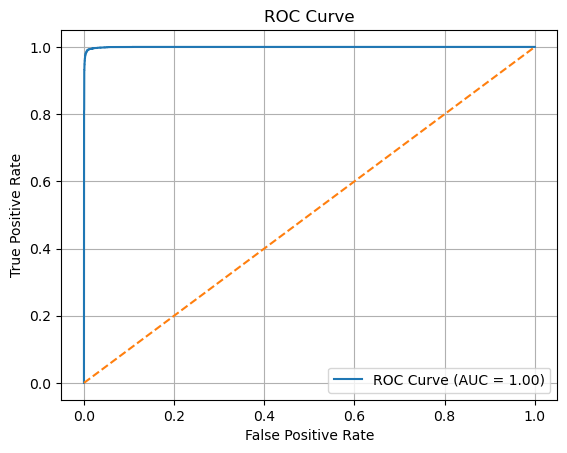

In [19]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

## Loading Check

In [ ]:
from transformers import BertTokenizer, BertForSequenceClassification

model_path = '../bert_model'

tokenizer = BertTokenizer.from_pretrained(model_path, local_files_only=True)
model = BertForSequenceClassification.from_pretrained(model_path, local_files_only=True)
print("Model loaded successfully.")

In [22]:
duplicates = tf_class_data['input'].duplicated().sum()
print(f"Number of duplicated inputs: {duplicates}")
print(f"Total number of inputs: {len(tf_class_data)}")
print(f"Duplicate Percentage: {duplicates/len(tf_class_data) * 100} %")

Number of duplicated inputs: 5930
Total number of inputs: 48302
Duplicate Percentage: 12.276924350958552 %
